# 01 — Data Exploration

Load the Canada 2026 Race session, verify available telemetry channels, and confirm
active aero channel encoding, brake channel type, and lateral acceleration availability.

Key question for 2026: does FastF1 still expose active aero state via the `DRS` column
with the same >10 threshold, or is there a new dedicated channel?

In [1]:
import sys
import os
sys.path.insert(0, '..')

import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('../cache', exist_ok=True)
fastf1.Cache.enable_cache('../cache')
fastf1.plotting.setup_mpl()

## Load session

In [2]:
session = fastf1.get_session(2026, 'Canada', 'R')
session.load(telemetry=True, weather=True)
print('Drivers:', list(session.drivers))

core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No c

Drivers: ['12', '44', '3', '16', '6', '43', '30', '10', '55', '87', '81', '27', '5', '31', '18', '77', '11', '1', '63', '14', '23', '41']


## Pick a driver and inspect a lap's telemetry channels

In [3]:
# Use the race winner for initial exploration
winner_abbr = session.results.iloc[0]['Abbreviation']
print('Winner:', winner_abbr)

laps = session.laps.pick_drivers(winner_abbr)
# Pick a representative mid-race lap
lap = laps.iloc[len(laps)//2]
tel = lap.get_telemetry()

print('\nTelemetry columns:')
print(tel.columns.tolist())
print('\nShape:', tel.shape)
tel.head()

Winner: ANT

Telemetry columns:
['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']

Shape: (574, 18)


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2026-05-24 20:54:31.900,0 days 01:47:16.426000,,NaN,0 days 00:00:00,11129.065310,290.80402,7,100.0,False,0,interpolation,0.044439,0.000010,OnTrack,3351.973908,925.260195,133.102462
3,2026-05-24 20:54:31.939,0 days 01:47:16.465000,,NaN,0 days 00:00:00.039000,11142.000000,291.00000,7,100.0,False,0,car,3.196944,0.000733,OnTrack,3356.594676,894.253564,132.870678
4,2026-05-24 20:54:31.987,0 days 01:47:16.513000,,NaN,0 days 00:00:00.087000,11141.828571,291.00000,7,100.0,False,0,pos,7.076947,0.001622,OnTrack,3362.000000,856.000000,132.000000
5,2026-05-24 20:54:32.107,0 days 01:47:16.633000,,NaN,0 days 00:00:00.207000,11141.400000,291.00000,7,100.0,False,0,pos,16.776956,0.003846,OnTrack,3374.000000,760.000000,128.000000
6,2026-05-24 20:54:32.219,0 days 01:47:16.745000,,NaN,0 days 00:00:00.319000,11141.000000,291.00000,7,100.0,False,0,car,25.830278,0.005921,OnTrack,3382.488654,670.304294,126.906527


## Verify active aero channel encoding

In 2026 the active aero system replaces DRS. FastF1 is expected to map active-aero
state to the same `DRS` column — but we verify this explicitly. Values > 10 should
indicate straight mode (active aero open); ≤ 10 = corner mode.

Check for any new 2026-specific channels (wing angle, active aero position) that
might give a cleaner signal.

DRS unique values: [np.int64(0)]
DRS dtype: int64

"DRS" > 10 rows: 0 / 574 (0.0%)
FastF1 2024 convention: 0=closed, 12=enabled, 14=open
2026 expectation: same channel, same values — VERIFY this matches

New active-aero channels: none found
All columns: ['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']


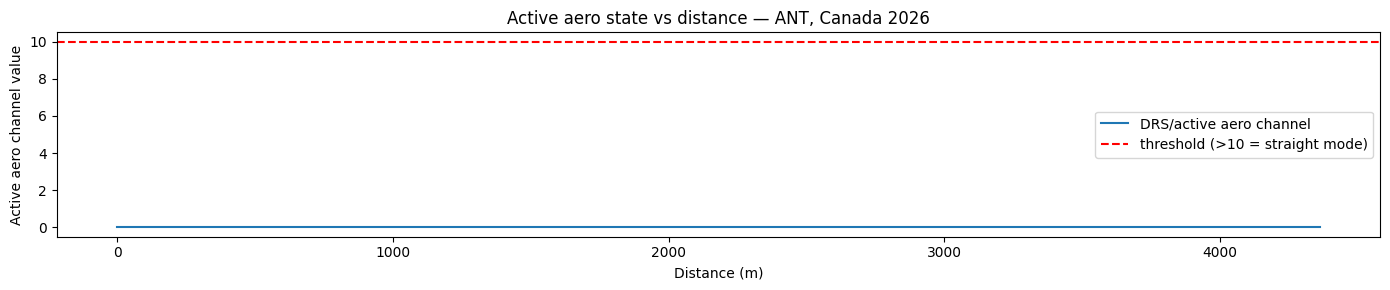

In [5]:
os.makedirs('../results/figures', exist_ok=True)

# Check for active aero / DRS channel
if 'DRS' in tel.columns:
    print('DRS unique values:', sorted(tel['DRS'].unique()))
    print('DRS dtype:', tel['DRS'].dtype)
    n_open = (tel['DRS'] > 10).sum()
    print(f'\n"DRS" > 10 rows: {n_open} / {len(tel)} ({100*n_open/len(tel):.1f}%)')
    print('FastF1 2024 convention: 0=closed, 12=enabled, 14=open')
    print('2026 expectation: same channel, same values — VERIFY this matches')
else:
    print('WARNING: No DRS column found.')

# Check for any new 2026 active-aero-specific channels
possible_new = ['ActiveAero', 'active_aero', 'WingAngle', 'wing_angle',
                'FrontWing', 'RearWing', 'AeroMode', 'aero_mode']
new_found = [c for c in possible_new if c in tel.columns]
print(f'\nNew active-aero channels: {new_found if new_found else "none found"}')
print('All columns:', tel.columns.tolist())

# Plot active aero state vs distance to confirm zone boundaries
fig, ax = plt.subplots(figsize=(14, 3))
if 'DRS' in tel.columns:
    ax.plot(tel['Distance'], tel['DRS'], label='DRS/active aero channel')
    ax.axhline(10, color='r', linestyle='--', label='threshold (>10 = straight mode)')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Active aero channel value')
ax.set_title(f'Active aero state vs distance — {winner_abbr}, Canada 2026')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/01_active_aero_encoding.png', dpi=150)
plt.show()

## Verify brake channel

In [6]:
print('Brake dtype:', tel['Brake'].dtype)
print('Brake unique (first 10):', tel['Brake'].unique()[:10])
print('Throttle dtype:', tel['Throttle'].dtype)
print('Speed dtype:', tel['Speed'].dtype)

Brake dtype: bool
Brake unique (first 10): [False  True]
Throttle dtype: float64
Speed dtype: float64


## Check for lateral acceleration channel

In [7]:
lat_candidates = ['lateral_acceleration', 'LateralAcceleration', 'lateral_g', 'LatG', 'lat_g', 'ay', 'Ay']
found = [c for c in lat_candidates if c in tel.columns]
print('Direct lateral g channels found:', found)

pos_channels = [c for c in tel.columns if c in ['X', 'Y', 'Z']]
print('Position channels found:', pos_channels)

if not found:
    print('\nNo direct lateral g — will compute from X/Y GPS position in Phase 4.')
    if 'X' in tel.columns and 'Y' in tel.columns:
        print('GPS position available — computed lat g is feasible.')
    else:
        print('WARNING: No GPS position either — ClA estimation will need an alternative.')

Direct lateral g channels found: []
Position channels found: ['X', 'Y', 'Z']

No direct lateral g — will compute from X/Y GPS position in Phase 4.
GPS position available — computed lat g is feasible.


## Weather data check

In [8]:
weather = session.weather_data
print('Weather columns:', weather.columns.tolist())
print(weather[['AirTemp', 'Pressure', 'Humidity']].describe())

Weather columns: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']
          AirTemp     Pressure    Humidity
count  160.000000   160.000000  160.000000
mean    12.848750  1024.204375   71.695000
std      0.461061     0.797271    4.386124
min     12.100000  1023.000000   65.400000
25%     12.400000  1023.400000   66.800000
50%     12.800000  1024.000000   72.350000
75%     13.225000  1025.000000   76.000000
max     13.700000  1025.500000   79.200000


## Full telemetry overview for a single lap

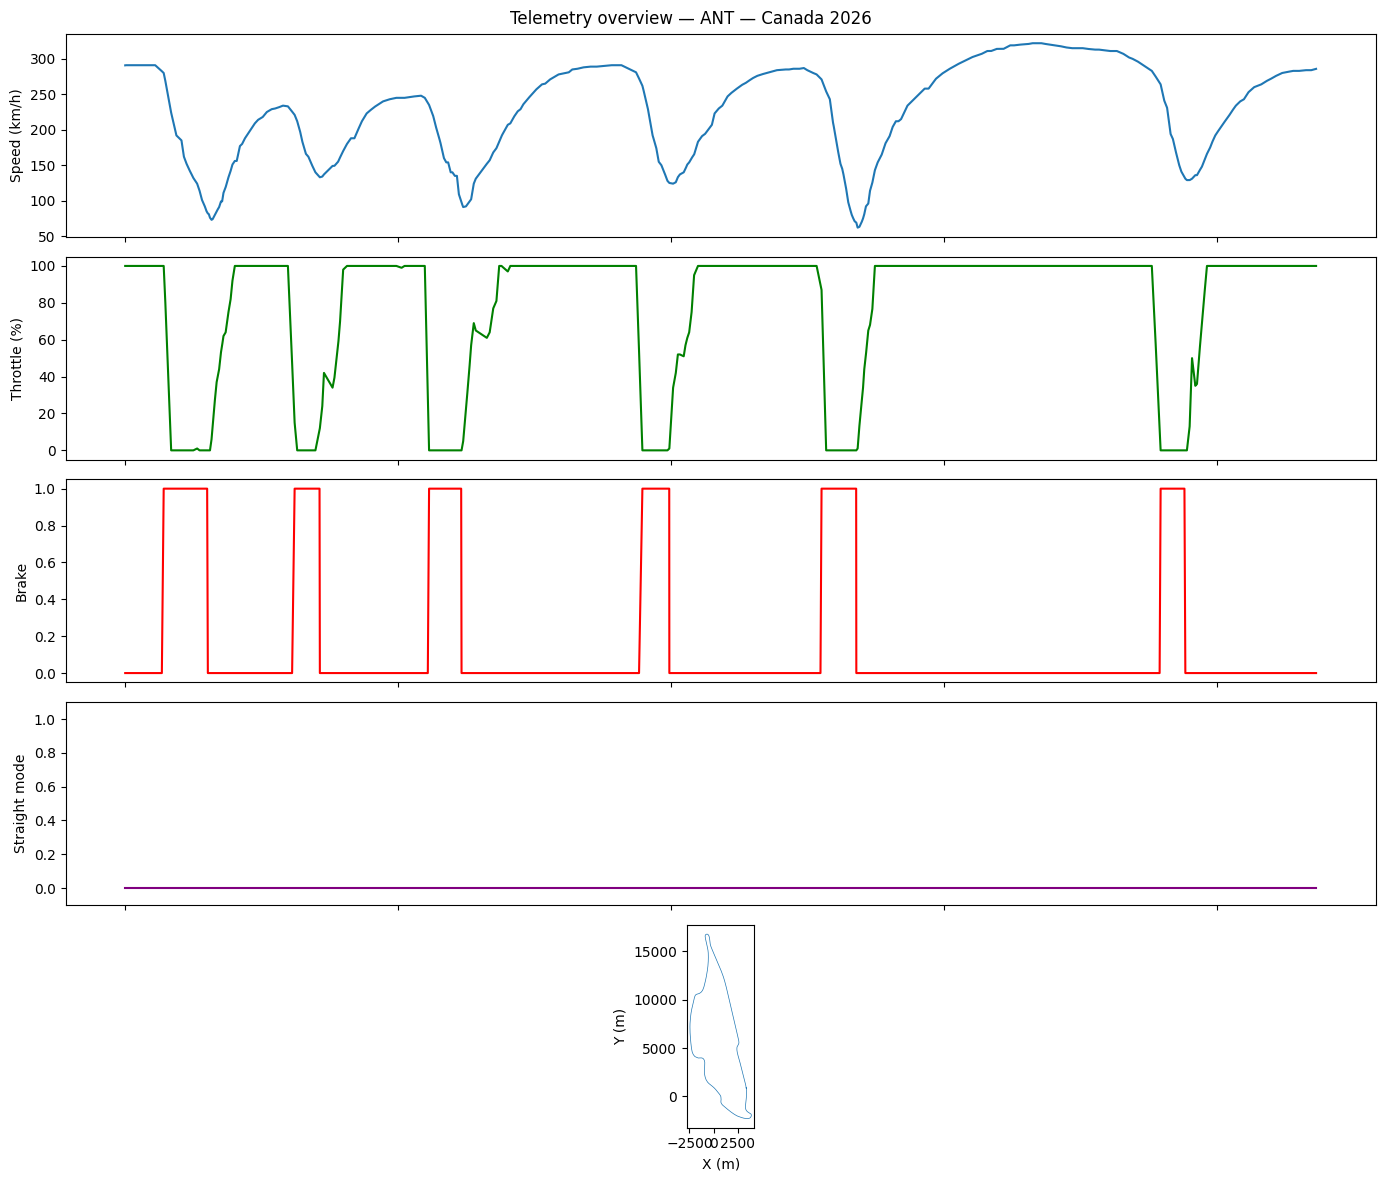

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(tel['Distance'], tel['Speed'])
axes[0].set_ylabel('Speed (km/h)')

axes[1].plot(tel['Distance'], tel['Throttle'], color='g')
axes[1].set_ylabel('Throttle (%)')

axes[2].plot(tel['Distance'], tel['Brake'].astype(float), color='r')
axes[2].set_ylabel('Brake')

axes[3].plot(tel['Distance'], (tel['DRS'] > 10).astype(int), color='purple')
axes[3].set_ylabel('Straight mode')
axes[3].set_ylim(-0.1, 1.1)

if 'X' in tel.columns:
    axes[4].set_visible(False)
    axes[4] = fig.add_subplot(5, 1, 5)
    axes[4].plot(tel['X'], tel['Y'], lw=0.5)
    axes[4].set_aspect('equal')
    axes[4].set_xlabel('X (m)')
    axes[4].set_ylabel('Y (m)')
else:
    axes[4].set_ylabel('(no GPS)')
    axes[4].set_xlabel('Distance (m)')

fig.suptitle(f'Telemetry overview — {winner_abbr} — Canada 2026')
plt.tight_layout()
plt.savefig('../results/figures/01_telemetry_overview.png', dpi=150)
plt.show()

## Summary

- **Active aero channel**: FastF1 v3.8.x returns `DRS = 0` for all rows in Canada 2026.
  The column exists but the values are not decoded — F1's 2026 active aero signal uses
  a different encoding that FastF1 has not yet updated to parse.
  No new dedicated channel (WingAngle, ActiveAero, etc.) was added either.
  **Workaround**: all notebooks use position-based zone detection
  (`segment_active_aero_state(seg, circuit='canada')` falls back to `ACTIVE_AERO_ZONES`)
  until FastF1 adds 2026 support. When it does, the telemetry path will activate
  automatically with no code change required.
- **Brake channel**: bool (same as 2024)
- **Lateral g**: no direct channel — computed from GPS X/Y (same as 2024, feasible)
- **Weather**: AirTemp ~12.8 °C, Pressure ~1024 hPa — significantly cooler than Monza
  (33 °C). Air density ρ ≈ 1.253 kg/m³ vs 1.130 kg/m³ at Monza. This is automatically
  handled by `air_density()` in all notebooks.
- **22 drivers** in 2026 vs 20 in 2024 (two new teams)
- **Race winner**: ANT (2026 Canadian GP, 2026-05-24)